In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", 100)

In [5]:
DATA_PATH = "../data/processed/final.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (8046, 23)


,genre_kids,duration,genre_family,genre_international,genre_drama,title_len,release_year,director_freq_log,years_to_platform,has_kids_words,has_mature_words,is_long_duration,genre_comedy,description_len,genre_romantic,year_added,cast_count,genre_crime,is_movie,genre_horror,genre_action,month_added,rating
0,0,90.0,0,0,0,20,2020,0.693147,1,0,1,0,0,152,0,2021,1,0,1,0,0,9,teen
1,0,2.0,0,1,1,13,2021,7.850104,0,1,1,0,0,147,0,2021,19,0,0,0,0,9,adult
2,0,1.0,0,1,0,9,2021,1.386294,0,1,1,0,0,146,0,2021,9,1,0,0,1,9,adult
3,0,1.0,0,0,0,21,2021,7.850104,0,0,0,0,0,147,0,2021,1,0,0,0,0,9,adult
4,0,2.0,0,1,0,12,2021,7.850104,0,0,0,0,0,152,1,2021,8,0,0,0,0,9,adult


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8046 entries, 0 to 8045
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   genre_kids           8046 non-null   int64  
 1   duration             8046 non-null   float64
 2   genre_family         8046 non-null   int64  
 3   genre_international  8046 non-null   int64  
 4   genre_drama          8046 non-null   int64  
 5   title_len            8046 non-null   int64  
 6   release_year         8046 non-null   int64  
 7   director_freq_log    8046 non-null   float64
 8   years_to_platform    8046 non-null   int64  
 9   has_kids_words       8046 non-null   int64  
 10  has_mature_words     8046 non-null   int64  
 11  is_long_duration     8046 non-null   int64  
 12  genre_comedy         8046 non-null   int64  
 13  description_len      8046 non-null   int64  
 14  genre_romantic       8046 non-null   int64  
 15  year_added           8046 non-null   int64  
 16 

In [7]:
df.describe(include="all")

,genre_kids,duration,genre_family,genre_international,genre_drama,title_len,release_year,director_freq_log,years_to_platform,has_kids_words,has_mature_words,is_long_duration,genre_comedy,description_len,genre_romantic,year_added,cast_count,genre_crime,is_movie,genre_horror,genre_action,month_added,rating
count,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.000000,8046.00000,8046.000000,8046.000000,8046
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,adult
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3748
mean,0.053194,66.800149,0.071837,0.479617,0.359185,17.750932,2016.324012,3.162400,2.566741,0.210291,0.209794,0.112603,0.046234,143.175739,0.113348,2018.890753,7.237882,0.057793,0.677852,0.04959,0.103530,6.618444,NaN
std,0.224434,49.980372,0.258234,0.499615,0.479791,10.674790,3.782073,3.227651,3.655243,0.407540,0.407187,0.316126,0.210005,9.904701,0.317038,1.492762,4.762093,0.233366,0.467328,0.21711,0.304668,3.413799,NaN
min,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2004.000000,0.693147,-2.000000,0.000000,0.000000,0.000000,0.000000,61.000000,0.000000,2015.000000,1.000000,0.000000,0.000000,0.00000,0.000000,1.000000,NaN
25%,0.000000,2.000000,0.000000,0.000000,0.000000,10.000000,2015.000000,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,140.000000,0.000000,2018.000000,3.000000,0.000000,0.000000,0.00000,0.000000,4.000000,NaN
50%,0.000000,87.000000,0.000000,0.000000,0.000000,15.000000,2017.000000,1.098612,1.000000,0.000000,0.000000,0.000000,0.000000,146.000000,0.000000,2019.000000,8.000000,0.000000,1.000000,0.00000,0.000000,7.000000,NaN
75%,0.000000,104.000000,0.000000,1.000000,1.000000,23.000000,2019.000000,7.850104,4.000000,0.000000,0.000000,0.000000,0.000000,149.000000,0.000000,2020.000000,10.000000,0.000000,1.000000,0.00000,0.000000,10.000000,NaN


In [8]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_df

,missing_count,missing_percent
genre_kids,0,0.0
duration,0,0.0
genre_family,0,0.0
genre_international,0,0.0
genre_drama,0,0.0
title_len,0,0.0
release_year,0,0.0
director_freq_log,0,0.0
years_to_platform,0,0.0
has_kids_words,0,0.0


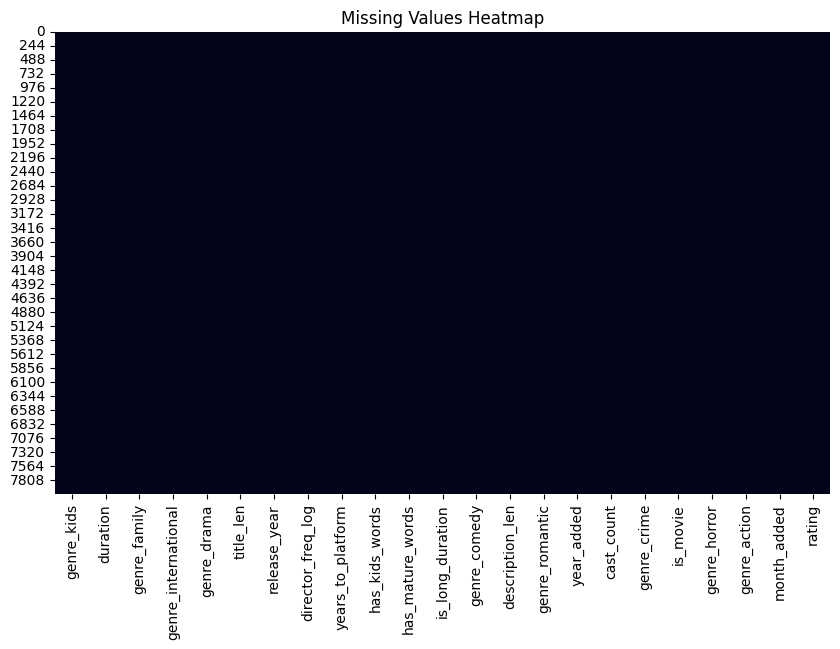

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [19]:
df.duplicated().sum()

np.int64(2)

In [20]:
TARGET = "rating"  

df[TARGET].value_counts()

rating
adult    3748
teen     3372
kids      846
other      80
Name: count, dtype: int64

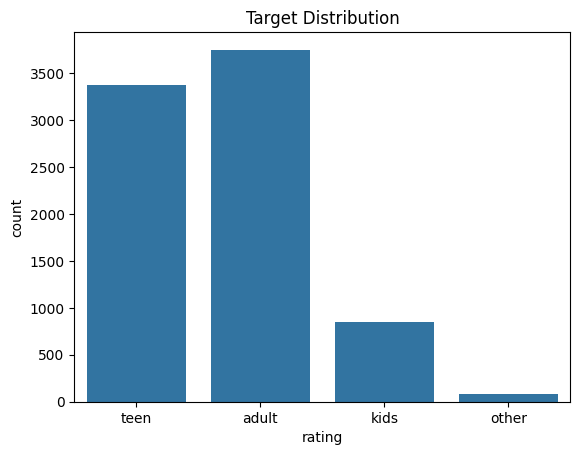

In [21]:
sns.countplot(x=df[TARGET])
plt.title("Target Distribution")
plt.show()

In [22]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

num_cols

['genre_kids',
 'duration',
 'genre_family',
 'genre_international',
 'genre_drama',
 'title_len',
 'release_year',
 'director_freq_log',
 'years_to_platform',
 'has_kids_words',
 'has_mature_words',
 'is_long_duration',
 'genre_comedy',
 'description_len',
 'genre_romantic',
 'year_added',
 'cast_count',
 'genre_crime',
 'is_movie',
 'genre_horror',
 'genre_action',
 'month_added']

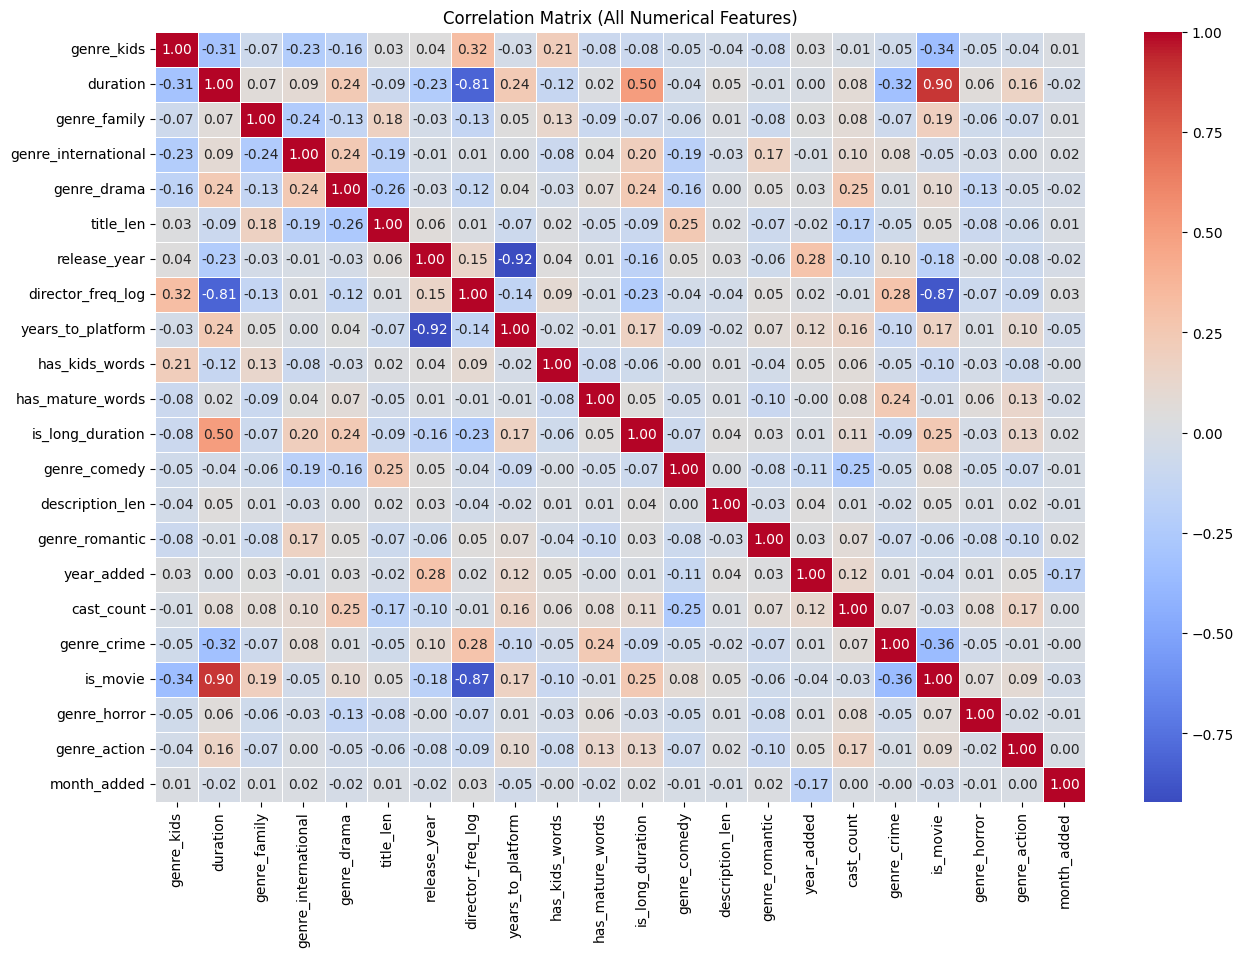

In [24]:

corr = df[num_cols].corr()

plt.figure(figsize=(15, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix (All Numerical Features)")
plt.show()

In [27]:
high_corr = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

high_corr

[('years_to_platform', 'release_year', np.float64(-0.9199874231524412))]

In [28]:
df[num_cols].skew().sort_values(ascending=False)

genre_comedy           4.322554
genre_horror           4.150182
genre_kids             3.982607
genre_crime            3.790768
genre_family           3.316913
genre_action           2.603282
is_long_duration       2.451515
genre_romantic         2.439759
years_to_platform      1.726027
title_len              1.460578
has_mature_words       1.425776
has_kids_words         1.422098
cast_count             1.280984
director_freq_log      0.740287
genre_drama            0.587132
description_len        0.306192
genre_international    0.081614
month_added           -0.033985
duration              -0.211736
year_added            -0.304220
is_movie              -0.761335
release_year          -1.206031
dtype: float64

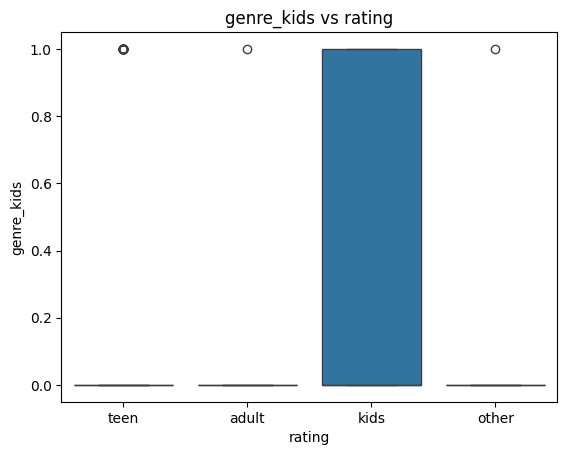

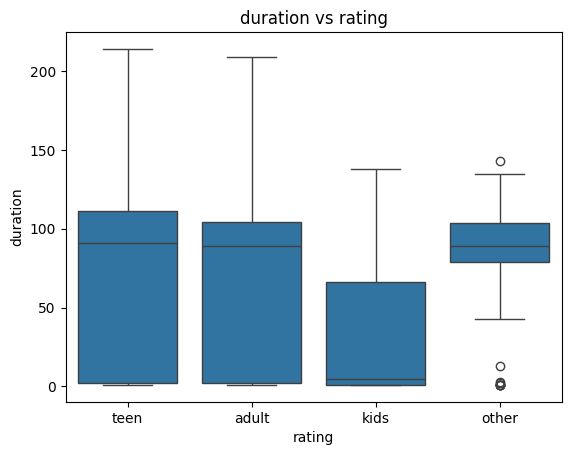

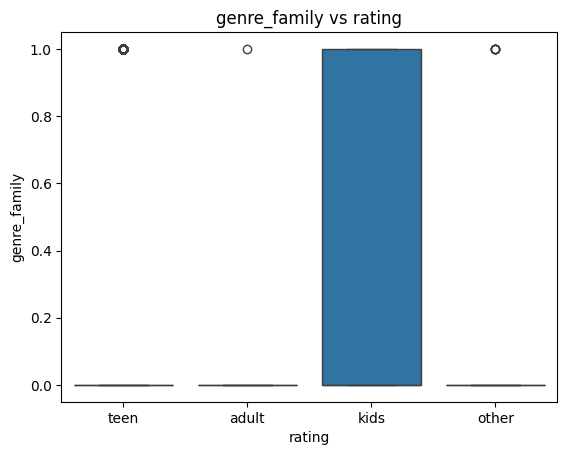

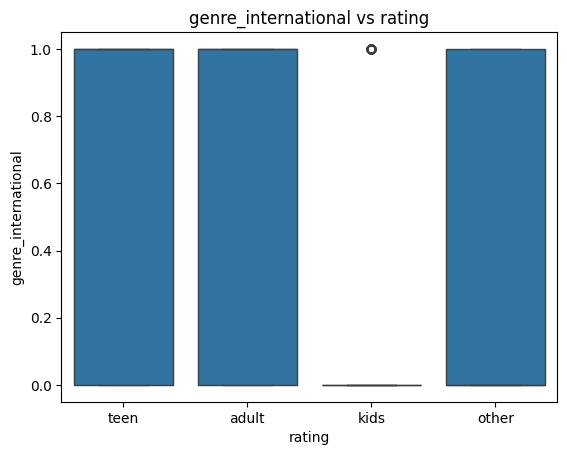

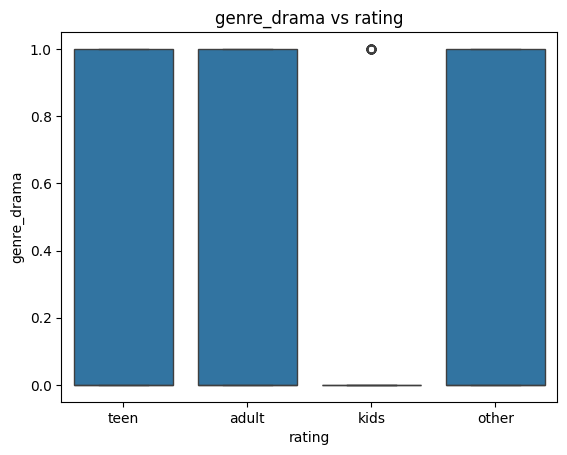

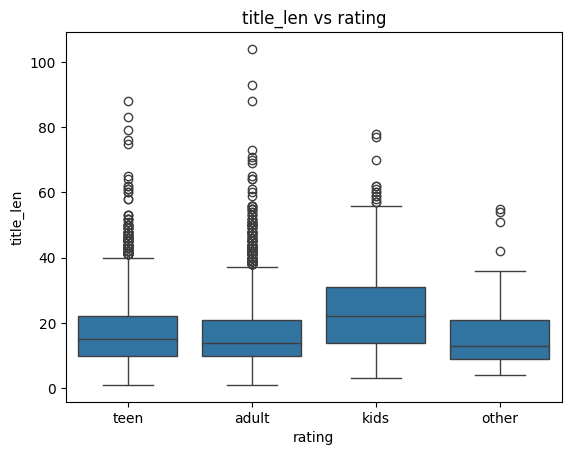

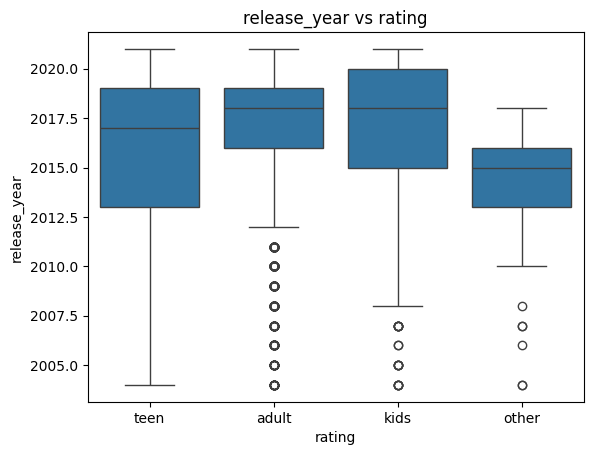

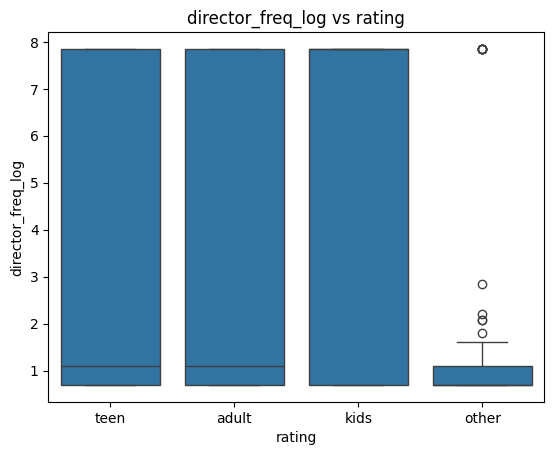

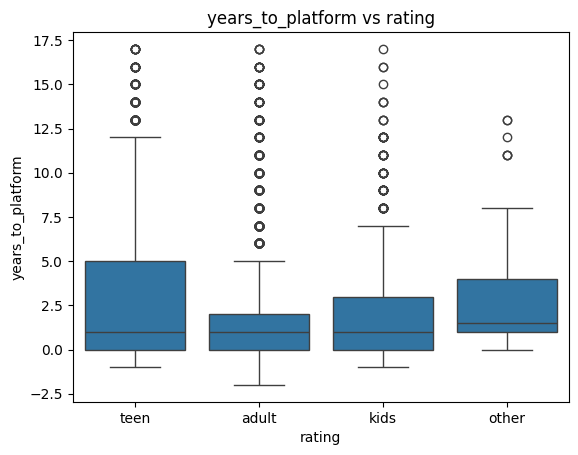

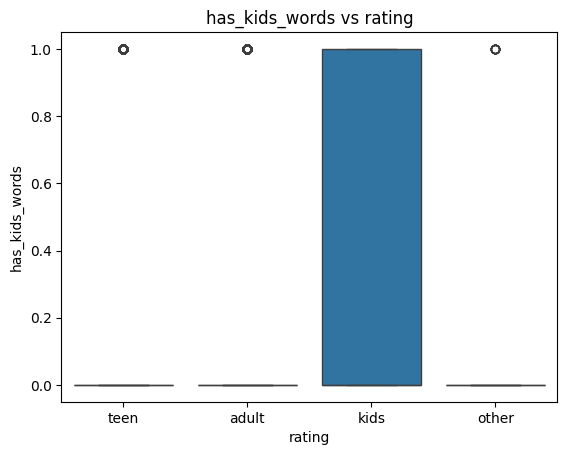

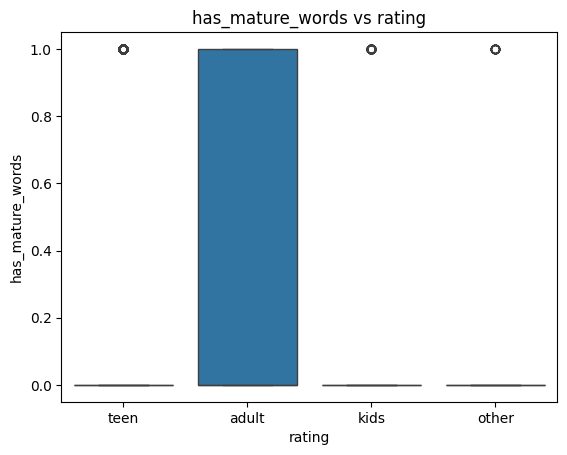

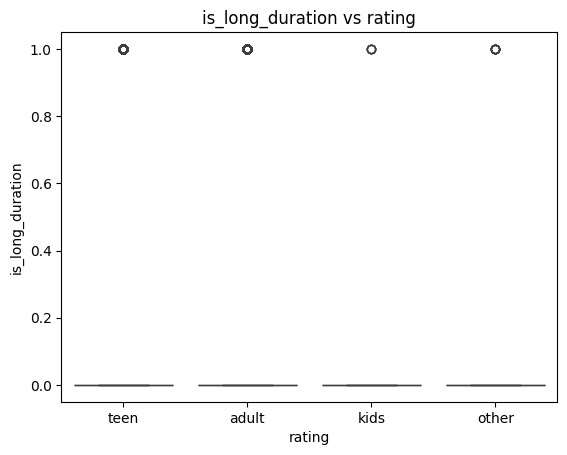

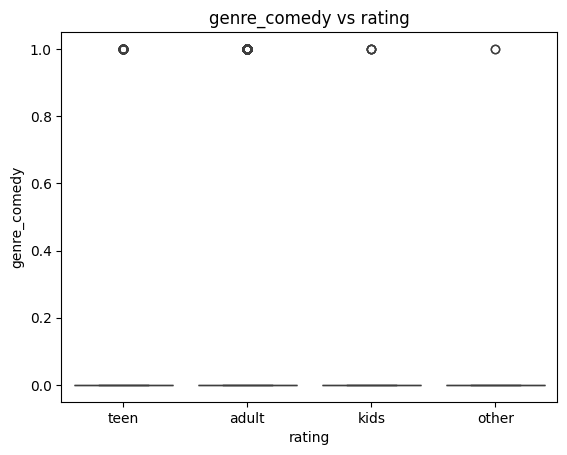

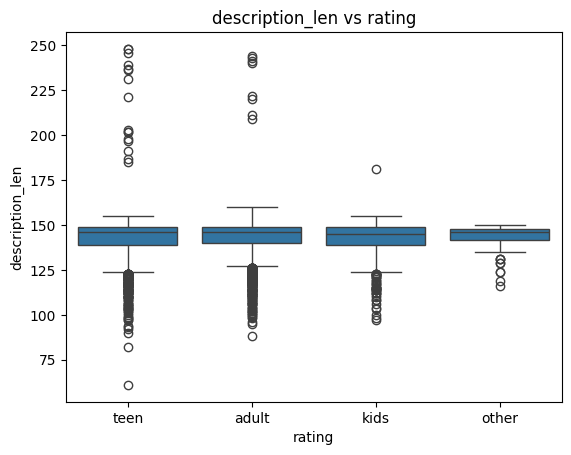

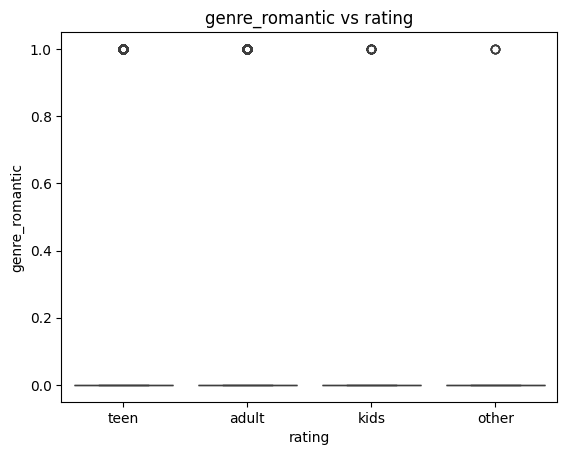

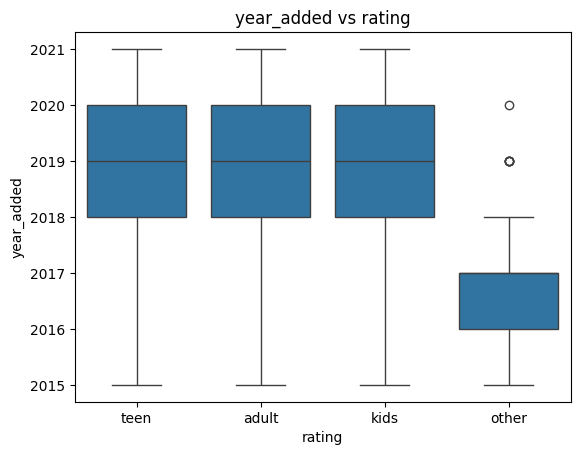

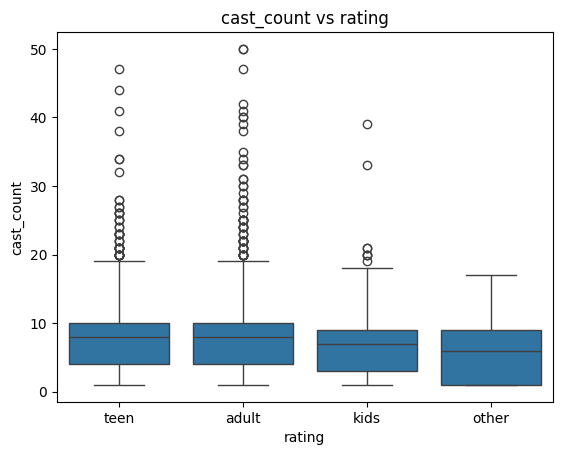

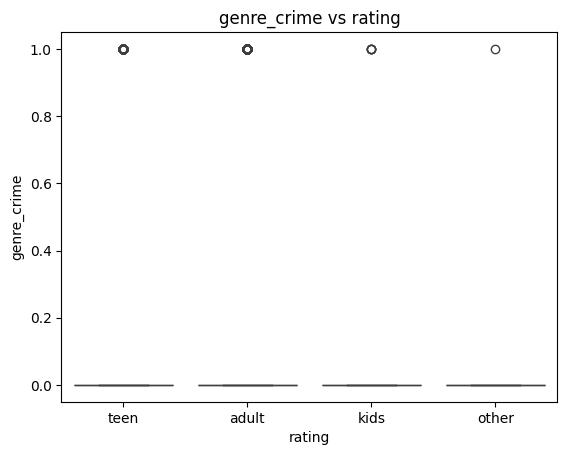

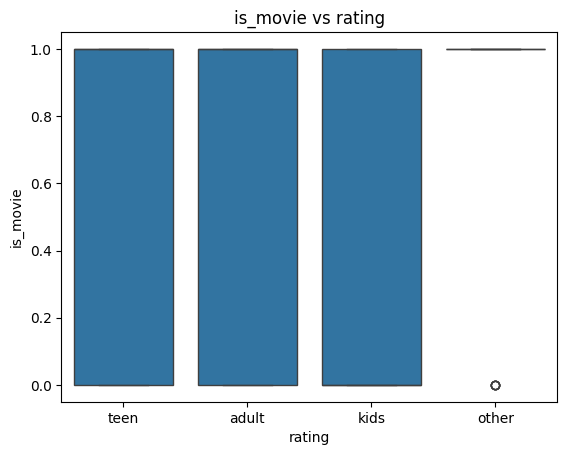

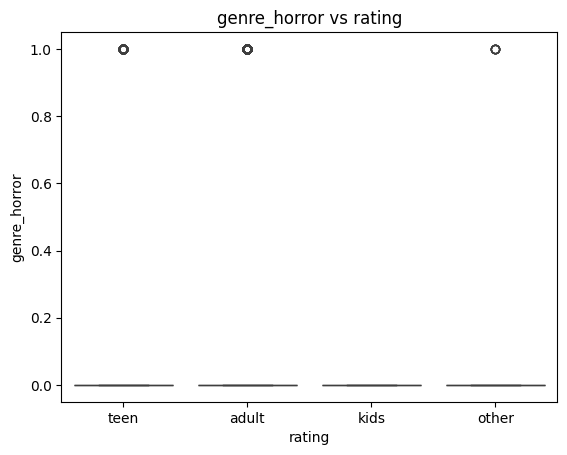

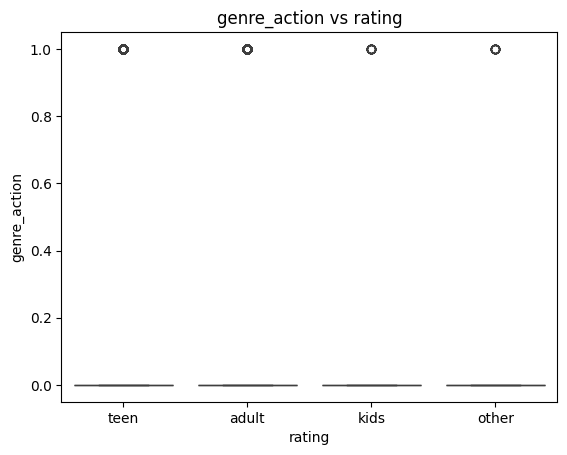

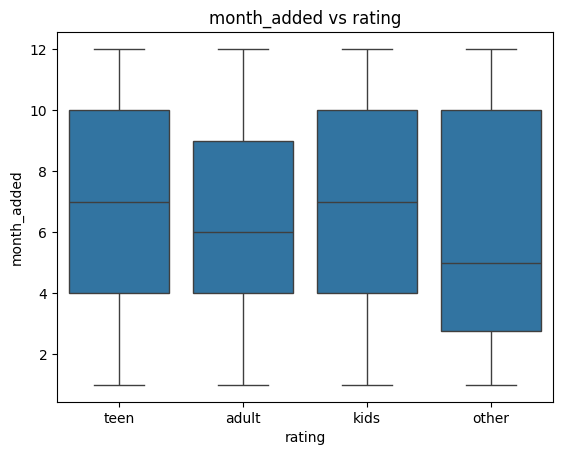

In [29]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[TARGET], y=df[col])
    plt.title(f"{col} vs {TARGET}")
    plt.show()